In [1]:
# 랜덤성 제어를 위한 표준 라이브러리 모듈을 불러옵니다.
import random
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler


# 데이터셋을 불러옵니다.
dat = pd.read_csv(Path("../../data/processed/data_selected.csv"), index_col=0)

# 재현 가능한 실험을 위해 시드 값을 고정합니다.
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 CUDA를, 없으면 CPU를 사용하도록 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DDQN에서 사용할 Q-Network 구조를 정의합니다.
# 데이터 수가 많지 않으므로 과적합 가능성을 염두에 두고 2개 은닉층을 사용합니다.
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.net(x)                         # (batch, 2)

# 경험을 저장하고 무작위 샘플링하기 위한 리플레이 버퍼를 정의합니다.
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(states).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones.astype(np.float32)).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# DDQN 에이전트를 정의합니다.
class DDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.95,
        lr=5e-4,
        batch_size=64,
        memory_size=100_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.online_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory_size)
        self.total_steps = 0

    def act(self, state, epsilon: float = None):
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        #online_net에서 현재 Q값 계산
        q_values = self.online_net(states).gather(1, actions)
        #online_net에서 다음 행동 선택 
        next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
        #target_net에서 다음 행동의 Q값 계산
        next_q_values = self.target_net(next_states).gather(1, next_actions)
        target_q = rewards + (1 - dones) * self.gamma * next_q_values
        loss = F.mse_loss(q_values, target_q.detach())
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.total_steps += 1
        if self.total_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return float(loss.item())

def encode_risk_labels(series):
    s = series.copy()
    # 문자열 타입이면 'High Risk' → 1, 'Low Risk' → 0 매핑
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.map({'Low Risk': 0, 'High Risk': 1})
        if s.isna().any():
            raise ValueError(f"알 수 없는 라벨 값이 있습니다: {series[s.isna()].unique()}")
    # 숫자형이면 그냥 int 변환
    return s.fillna(0).astype(int).to_numpy()

# ---- 데이터 준비 (Train/Valid/Test Split 먼저, 그 후 Scaling) ----

risk_label_col = "Risk_Label"
feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

risk_label_data = encode_risk_labels(dat[risk_label_col])
feature_data_raw = dat[feature_cols].fillna(0.0).to_numpy()
n_steps = len(dat)

train_end = int(n_steps * 0.45)
valid_end = int(n_steps * 0.80)
test_ratio = 1 - (valid_end / n_steps)

train_indices = np.arange(0, train_end)
valid_indices = np.arange(train_end, valid_end)
test_indices  = np.arange(valid_end, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices]

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices]
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tuning/selection 분할이 불가능합니다. split 비율을 조정하세요.")
valid_split_point = int(len(valid_label) * 0.65)
valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]
valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices]

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    imbalance = (n1 / max(n0, 1)) if n_total > 0 else 0.0
    print(f"{name:>5} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={imbalance:.4f})")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary (Before ADASYN)")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTun", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

# 보상 계산에 사용할 class_ratio는 원본 train 기준으로 고정합니다.
n_negative_original = (train_label == 0).sum()
n_positive_original = (train_label == 1).sum()
class_ratio_reward = n_positive_original / max(n_negative_original, 1)
print(f"Reward class ratio (original train): {class_ratio_reward:.4f}")

# ---- ADASYN을 적용하지 않고 원본 학습 데이터를 그대로 사용 ----
train_feature = train_feature_raw.astype(np.float32)
train_label = train_label.astype(np.int64)

scaler = MinMaxScaler()
scaler.fit(train_feature)

train_feature = scaler.transform(train_feature).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

print("=" * 60)
print("Data Split Information")
print("=" * 60)
print(f"Total samples: {n_steps}")
print(f"Train set: {len(train_label)} samples")
print(f"  - Class 0: {(train_label==0).sum()}, Class 1: {(train_label==1).sum()}")
print(f"Valid(Tune) set: {len(valid_tune_label)} samples")
print(f"  - Class 0: {(valid_tune_label==0).sum()}, Class 1: {(valid_tune_label==1).sum()}")
print(f"Valid(Select) set: {len(valid_select_label)} samples")
print(f"  - Class 0: {(valid_select_label==0).sum()}, Class 1: {(valid_select_label==1).sum()}")
print(f"Test set: {len(test_indices)} samples ({test_ratio*100:.1f}%)")
print(f"  - Class 0: {(test_label==0).sum()}, Class 1: {(test_label==1).sum()}")

# 원본 학습 세트의 클래스 비율을 그대로 사용합니다.
n_negative = (train_label == 0).sum()
n_positive = (train_label == 1).sum()
class_ratio = class_ratio_reward

print(f"\nClass ratio (train set): {n_positive / max(n_negative, 1):.4f}")
print(f"Class ratio used for reward: {class_ratio:.4f}")
print("=" * 60)

state_dim = len(feature_cols)
action_dim = 2

# ---- DDQN reward / sampling 설정 ----
# final2 계열의 안정적인 보상 체계를 사용합니다.
# 목표: FP는 소폭 억제하되, FN이 크게 늘지 않도록 FN 벌점은 강하게 유지합니다.
HIGH_RISK_PROB = 0.65

def compute_reward(action, actual_label, class_ratio=None):
    action = int(action)
    actual_label = int(actual_label)

    # action: 0 = Low risk 예측, 1 = High risk 예측
    # actual_label: 0 = 실제 Low risk, 1 = 실제 High risk
    if actual_label == 0 and action == 0:
        return 0.4      # TN
    elif actual_label == 0 and action == 1:
        return -0.9     # FP: final2보다 소폭 강화
    elif actual_label == 1 and action == 1:
        return 4.0      # TP
    elif actual_label == 1 and action == 0:
        return -6.0     # FN: 완화하지 않음

# train_label에서 High Risk 인덱스를 미리 계산
high_risk_indices = np.where(train_label == 1)[0]
print(f"High Risk 인덱스 수 (train): {len(high_risk_indices)}")

def get_balanced_start_idx(max_steps, high_risk_prob=HIGH_RISK_PROB):
    """
    high_risk_prob 확률로 High Risk가 윈도우 안에
    반드시 포함되는 start_idx를 반환.
    
    나머지 확률로는 기존 랜덤 방식 사용.
    시계열 순서는 항상 유지됨.
    
    Parameters:
        max_steps: 에피소드 길이 (500)
        high_risk_prob: High Risk 포함 윈도우 선택 확률
    
    Returns:
        start_idx: 에피소드 시작 인덱스
    """
    n = len(train_feature)
    max_start = n - max_steps - 1
    if max_start < 0:
        raise ValueError("max_steps가 train_feature 길이에 비해 너무 큽니다.")
    
    if np.random.random() < high_risk_prob and len(high_risk_indices) > 0:
        # High Risk 인덱스 중 하나를 무작위 선택
        hr_idx = np.random.choice(high_risk_indices)
        
        # 이 hr_idx가 윈도우 안에 포함되는
        # start_idx의 유효 범위 계산:
        # 조건: start_idx <= hr_idx <= start_idx + max_steps - 1
        # → low = hr_idx - max_steps + 1
        # → high = hr_idx
        low  = max(0, hr_idx - max_steps + 1)
        high = min(max_start, hr_idx)
        
        if low > high:
            # 유효 범위가 없으면 (데이터 끝부분 등) 랜덤
            return np.random.randint(0, max_start + 1)
        
        # 유효 범위 안에서 랜덤 선택
        # → High Risk가 윈도우 앞/중간/뒤 어디든 포함됨
        return int(np.random.randint(low, high + 1))
    
    else:
        # 기존 방식: 완전 랜덤
        return int(np.random.randint(0, max_start + 1))

Class Ratio Summary (Before ADASYN)
Train | n=1848 | class0=1638 (88.64%) | class1= 210 (11.36%) | c1/c0=0.1282)
ValTun | n= 934 | class0= 829 (88.76%) | class1= 105 (11.24%) | c1/c0=0.1267)
ValSel | n= 504 | class0= 427 (84.72%) | class1=  77 (15.28%) | c1/c0=0.1803)
 Test | n= 822 | class0= 723 (87.96%) | class1=  99 (12.04%) | c1/c0=0.1369)
Reward class ratio (original train): 0.1282
Data Split Information
Total samples: 4108
Train set: 1848 samples
  - Class 0: 1638, Class 1: 210
Valid(Tune) set: 934 samples
  - Class 0: 829, Class 1: 105
Valid(Select) set: 504 samples
  - Class 0: 427, Class 1: 77
Test set: 822 samples (20.0%)
  - Class 0: 723, Class 1: 99

Class ratio (train set): 0.1282
Class ratio used for reward: 0.1282
High Risk 인덱스 수 (train): 210



HYPERPARAMETER GRID SEARCH WITH Q-MARGIN THRESHOLD (Total: 24 combinations)

[1/24] gamma=0.50, lr=1e-04, eps_decay=0.990, bs=32
  Ep  20 | Tune H1: 0.4332 G-mean: 0.6728 F1: 0.3194 (Sens: 0.6571, Spec: 0.6888, Pre: 0.2110, FP: 258, FN: 36) | Th: -0.000918 | Best H1: 0.4332
  Ep  40 | Tune H1: 0.4283 G-mean: 0.6609 F1: 0.3168 (Sens: 0.6095, Spec: 0.7165, Pre: 0.2140, FP: 235, FN: 41) | Th: 0.168947 | Best H1: 0.4361
  Ep  60 | Tune H1: 0.4332 G-mean: 0.6728 F1: 0.3194 (Sens: 0.6571, Spec: 0.6888, Pre: 0.2110, FP: 258, FN: 36) | Th: 0.076953 | Best H1: 0.4361
  Ep  80 | Tune H1: 0.4283 G-mean: 0.6609 F1: 0.3168 (Sens: 0.6095, Spec: 0.7165, Pre: 0.2140, FP: 235, FN: 41) | Th: -0.053818 | Best H1: 0.4361
  Ep 100 | Tune H1: 0.4506 G-mean: 0.6596 F1: 0.3422 (Sens: 0.5524, Spec: 0.7877, Pre: 0.2479, FP: 176, FN: 47) | Th: 0.284200 | Best H1: 0.4506
  Ep 120 | Tune H1: 0.4522 G-mean: 0.6481 F1: 0.3473 (Sens: 0.5143, Spec: 0.8166, Pre: 0.2621, FP: 152, FN: 51) | Th: 0.373050 | Best H1: 0.457

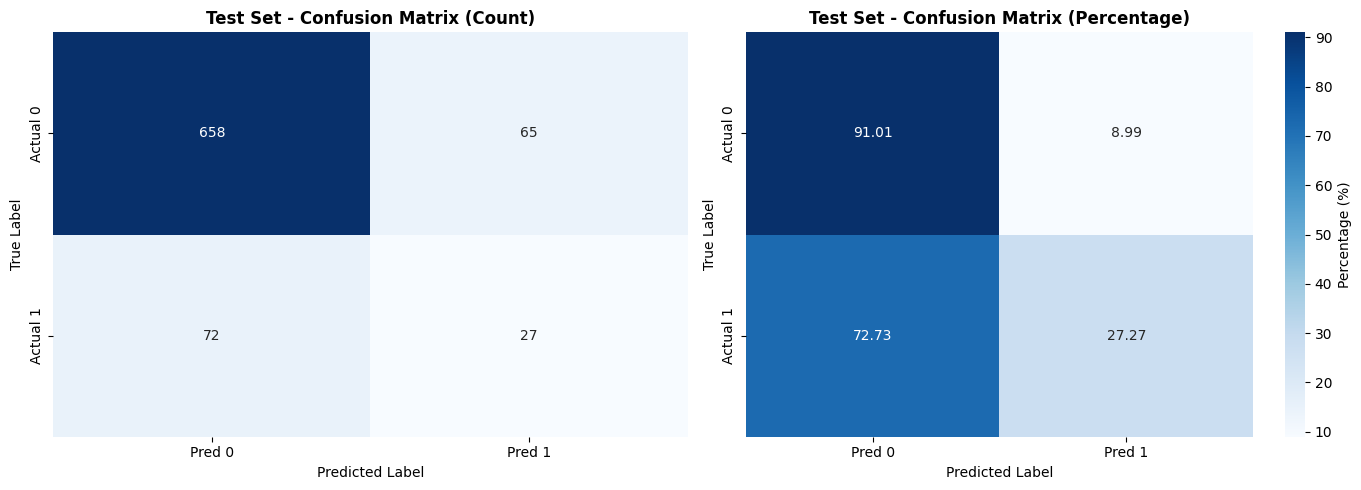


상세 메트릭 (Test Set):
Sensitivity (Recall for Class 1): 0.2727
Specificity (Recall for Class 0): 0.9101
Precision (Class 1):              0.2935
F1-Score:                         0.2827
G-mean:                           0.4982
H1 (G-mean & F1):                 0.3607

VALIDATION SET vs TEST SET 성능 비교

Validation(Selection) Set - H1: 0.4754
Test Set - H1:                  0.3607
Difference (Valid - Test):      0.1147

Validation Confusion Matrix:
[[373  54]
 [ 45  32]]

Test Confusion Matrix:
[[658  65]
 [ 72  27]]


In [ ]:
# ---- Validation 기반 하이퍼파라미터 Grid Search + Q-margin threshold ----
from itertools import product

param_grid = {
    "gamma": [0.5, 0.9],
    "lr": [1e-4, 5e-4, 1e-3],
    "epsilon_decay": [0.99, 0.995],
    "batch_size": [32, 64],
}

# Q-margin threshold 설정
# margin = Q(High risk) - Q(Low risk)
# threshold가 커질수록 High risk 예측이 줄어 FP가 줄 수 있지만, FN은 늘 수 있습니다.
# 현재 목표는 "TP를 크게 잃지 않으면서 FP를 줄이는 것"입니다.
# 따라서 H1 최대만 보지 않고, validation에서 specificity / predicted-high 비율도 함께 제한합니다.
H1_TOLERANCE = 0.970          # best H1의 97.0% 이상 후보까지 허용: FP를 줄일 여지를 줌
SENS_RATIO_FLOOR = 0.85       # best-H1 후보의 sensitivity 대비 85% 이상 유지
MIN_SENSITIVITY_ABS = 0.65    # TP 급락 방지용 절대 sensitivity 하한
MIN_SPECIFICITY_ABS = 0.65    # FP 폭증 방지용 절대 specificity 하한
MAX_PRED_HIGH_RATIO_CAP = 0.35  # validation에서 High risk 예측 비율 상한


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    gmean = float(np.sqrt(sensitivity * specificity))
    f1 = float(2 * precision * sensitivity / (precision + sensitivity)) if (precision + sensitivity) > 0 else 0.0
    h1 = float(2 * gmean * f1 / (gmean + f1)) if (gmean + f1) > 0 else 0.0

    return {
        "gmean": gmean,
        "f1": f1,
        "h1": h1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "cm": cm,
    }


def predict_q_values(model, features):
    model.eval()
    q_list = []
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t).detach().cpu().numpy()[0]
            q_list.append(q_values)
    return np.asarray(q_list)


def get_q_margin(model, features):
    q_values = predict_q_values(model, features)
    margins = q_values[:, 1] - q_values[:, 0]
    return margins, q_values


def predict_labels_qmargin(model, features, threshold=0.0):
    margins, _ = get_q_margin(model, features)
    return (margins >= threshold).astype(int)


def predict_labels_argmax(model, features):
    # 비교용: threshold=0과 거의 같은 역할이지만, 동률 처리 방식은 argmax 기준입니다.
    preds = []
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t)
            preds.append(int(torch.argmax(q_values, dim=1).item()))
    return np.array(preds)


def evaluate_qmargin(model, x_valid, y_valid, threshold):
    preds = predict_labels_qmargin(model, x_valid, threshold=threshold)
    return compute_metrics(y_valid, preds)


def make_threshold_candidates(margins):
    margins = np.asarray(margins, dtype=float)
    finite_margins = margins[np.isfinite(margins)]
    if len(finite_margins) == 0:
        return np.array([0.0])

    qs = np.linspace(0.01, 0.99, 99)
    candidates = np.quantile(finite_margins, qs)
    candidates = np.concatenate([
        candidates,
        np.array([0.0, finite_margins.min() - 1e-6, finite_margins.max() + 1e-6])
    ])
    return np.unique(np.round(candidates, 10))


def select_qmargin_threshold(model, x_valid, y_valid,
                             h1_tolerance=H1_TOLERANCE,
                             sens_ratio_floor=SENS_RATIO_FLOOR,
                             min_sensitivity_abs=MIN_SENSITIVITY_ABS,
                             min_specificity_abs=MIN_SPECIFICITY_ABS,
                             max_pred_high_ratio_cap=MAX_PRED_HIGH_RATIO_CAP):
    """
    validation에서 Q-margin threshold를 선택합니다.

    기존 방식은 H1과 sensitivity를 너무 강하게 보존해서 High risk 예측이 과도하게 많아질 수 있습니다.
    이 버전은 다음 원칙으로 선택합니다.

    1) H1이 best H1 근처인 후보만 유지
    2) sensitivity가 너무 무너지지 않는 후보만 유지
    3) specificity와 predicted-high 비율로 FP 폭증을 막음
    4) 남은 후보 중 FP가 가장 작은 threshold 선택

    목표: TP를 크게 깎지 않으면서 FP를 줄이는 Q-margin threshold 선택.
    """
    margins, _ = get_q_margin(model, x_valid)
    thresholds = make_threshold_candidates(margins)

    rows = []
    n_valid = len(y_valid)
    actual_high_ratio = float(np.mean(y_valid)) if n_valid > 0 else 0.0

    # 실제 high-risk 비율이 10~15% 수준일 때 predicted-high가 40% 이상이면 FP가 폭증하기 쉬움.
    # validation 기준으로 실제 high-risk 비율의 2.5배 또는 35% 중 작은 값을 상한으로 둠.
    pred_high_ratio_cap = min(max_pred_high_ratio_cap, max(0.20, actual_high_ratio * 2.5))

    for th in thresholds:
        preds = (margins >= th).astype(int)
        m = compute_metrics(y_valid, preds)
        pred_high = int(m["fp"] + m["tp"])
        pred_high_ratio = pred_high / n_valid if n_valid > 0 else 0.0
        row = {
            "threshold": float(th),
            **{k: v for k, v in m.items() if k != "cm"},
            "pred_high": pred_high,
            "pred_high_ratio": pred_high_ratio,
            "actual_high_ratio": actual_high_ratio,
            "pred_high_ratio_cap": pred_high_ratio_cap,
        }
        rows.append(row)

    result_df = pd.DataFrame(rows)
    best_idx = result_df["h1"].idxmax()
    best_h1 = float(result_df.loc[best_idx, "h1"])
    best_h1_sens = float(result_df.loc[best_idx, "sensitivity"])

    sens_floor = max(min_sensitivity_abs, best_h1_sens * sens_ratio_floor)

    # 1차: TP를 지키면서 FP를 줄일 수 있는 후보
    candidates = result_df[
        (result_df["h1"] >= best_h1 * h1_tolerance) &
        (result_df["sensitivity"] >= sens_floor) &
        (result_df["specificity"] >= min_specificity_abs) &
        (result_df["pred_high_ratio"] <= pred_high_ratio_cap)
    ].copy()

    # 2차 fallback: specificity / pred_high 제한이 너무 강하면 완화
    if len(candidates) == 0:
        candidates = result_df[
            (result_df["h1"] >= best_h1 * h1_tolerance) &
            (result_df["sensitivity"] >= sens_floor)
        ].copy()

    # 3차 fallback: 그래도 없으면 H1을 조금 더 완화
    if len(candidates) == 0:
        candidates = result_df[
            (result_df["h1"] >= best_h1 * 0.95) &
            (result_df["sensitivity"] >= max(0.60, best_h1_sens * 0.80))
        ].copy()

    if len(candidates) == 0:
        candidates = result_df.loc[[best_idx]].copy()

    # FP 감소가 1순위. 단, 위 필터로 TP 급락은 먼저 막아둠.
    candidates = candidates.sort_values(
        by=["fp", "pred_high_ratio", "h1", "precision", "specificity", "sensitivity"],
        ascending=[True, True, False, False, False, False]
    ).reset_index(drop=True)

    selected = candidates.iloc[0].to_dict()
    selected_threshold = float(selected["threshold"])
    selected_metrics = evaluate_qmargin(model, x_valid, y_valid, selected_threshold)

    # 확인용 threshold table은 H1 순이 아니라 선택 기준 확인이 쉽도록 H1 기준 정렬 유지
    return selected_threshold, selected_metrics, result_df.sort_values("h1", ascending=False).reset_index(drop=True)


# ---- Grid Search ----
grid_search_results = []
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print("\n" + "=" * 80)
print(f"HYPERPARAMETER GRID SEARCH WITH Q-MARGIN THRESHOLD (Total: {len(param_combinations)} combinations)")
print("=" * 80)

patience = 25
min_episodes = 60
best_overall_select_h1 = -1.0
best_overall_params = None
best_overall_threshold = 0.0

for idx, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    gamma, lr, epsilon_decay, batch_size = params

    # 각 조합마다 동일한 초기 조건으로 시작
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    print(f"\n[{idx+1}/{len(param_combinations)}] gamma={gamma:.2f}, lr={lr:.0e}, eps_decay={epsilon_decay:.3f}, bs={batch_size}")

    agent_tune = DDQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=gamma,
        lr=lr,
        batch_size=batch_size,
        memory_size=50_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=epsilon_decay,
    )

    episodes_tune = 200
    max_steps_tune = 500
    best_tune_h1 = -1.0
    best_tune_threshold = 0.0
    best_tune_state_dict = None
    patience_counter = 0

    for ep in range(1, episodes_tune + 1):
        start_idx = get_balanced_start_idx(max_steps_tune, high_risk_prob=HIGH_RISK_PROB)
        episode_reward = 0.0

        for i in range(max_steps_tune):
            state = train_feature[start_idx + i]
            next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
            actual_label = train_label[start_idx + i]

            action = agent_tune.act(state)
            reward = compute_reward(action, actual_label, class_ratio)
            done = i == (max_steps_tune - 1)

            agent_tune.memory.push(state, action, reward, next_state, done)
            _ = agent_tune.update()
            episode_reward += reward

        agent_tune.decay_epsilon()

        # 5 에피소드마다 valid_tune에서 Q-margin threshold까지 함께 선택
        if ep % 5 == 0:
            agent_tune.online_net.eval()
            tune_threshold, tune_metrics, _ = select_qmargin_threshold(
                agent_tune.online_net, valid_tune_feature, valid_tune_label
            )
            agent_tune.online_net.train()

            if tune_metrics["h1"] > best_tune_h1:
                best_tune_h1 = tune_metrics["h1"]
                best_tune_threshold = tune_threshold
                patience_counter = 0
                best_tune_state_dict = {k: v.detach().cpu().clone() for k, v in agent_tune.online_net.state_dict().items()}
            else:
                patience_counter += 1

            if ep % 20 == 0:
                print(
                    f"  Ep {ep:3d} | Tune H1: {tune_metrics['h1']:.4f} "
                    f"G-mean: {tune_metrics['gmean']:.4f} F1: {tune_metrics['f1']:.4f} "
                    f"(Sens: {tune_metrics['sensitivity']:.4f}, Spec: {tune_metrics['specificity']:.4f}, "
                    f"Pre: {tune_metrics['precision']:.4f}, FP: {tune_metrics['fp']}, FN: {tune_metrics['fn']}) "
                    f"| Th: {tune_threshold:.6f} | Best H1: {best_tune_h1:.4f}"
                )

            if ep > min_episodes and patience_counter >= patience:
                break

    # Tune에서 가장 좋은 모델과 threshold를 사용하여 Selection 데이터 평가
    agent_tune.online_net.eval()
    if best_tune_state_dict is not None:
        agent_tune.online_net.load_state_dict(best_tune_state_dict)

    select_metrics = evaluate_qmargin(
        agent_tune.online_net, valid_select_feature, valid_select_label, best_tune_threshold
    )

    grid_search_results.append({
        "params": param_dict,
        "best_tune_h1": best_tune_h1,
        "tune_threshold": best_tune_threshold,
        "select_h1": select_metrics["h1"],
        "select_gmean": select_metrics["gmean"],
        "select_f1": select_metrics["f1"],
        "select_sensitivity": select_metrics["sensitivity"],
        "select_specificity": select_metrics["specificity"],
        "select_precision": select_metrics["precision"],
        "select_fp": select_metrics["fp"],
        "select_fn": select_metrics["fn"],
    })

    if select_metrics["h1"] > best_overall_select_h1:
        best_overall_select_h1 = select_metrics["h1"]
        best_overall_params = param_dict
        best_overall_threshold = best_tune_threshold

# H1 우선, 같은 수준이면 FP가 적은 조합을 위로 정렬
grid_search_results.sort(key=lambda x: (x["select_h1"], -x["select_fp"], x["select_precision"]), reverse=True)

print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETERS")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(
        f"{i+1}. H1: {result['select_h1']:.4f} | "
        f"G-mean: {result['select_gmean']:.4f} | F1: {result['select_f1']:.4f} | "
        f"Sens: {result['select_sensitivity']:.4f} | Prec: {result['select_precision']:.4f} | "
        f"FP: {result['select_fp']} | FN: {result['select_fn']} | "
        f"Th: {result['tune_threshold']:.6f} | Params: {result['params']}"
    )

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection H1: {best_overall_select_h1:.4f}")
print(f"Threshold selected during grid search: {best_overall_threshold:.6f}")
print("=" * 80)


# ---- 최적 파라미터로 본 학습 ----
print("\nTraining with best hyperparameters...")
agent = DDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gamma=best_overall_params["gamma"],
    lr=best_overall_params["lr"],
    batch_size=best_overall_params["batch_size"],
    memory_size=50_000,
    target_update=2000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=best_overall_params["epsilon_decay"],
)

episodes = 800
max_steps = 500
scores = []
valid_scores = []
best_ckpt_valid_h1 = -1.0
best_ckpt_epoch = 0
best_ckpt_state_dict = None
best_ckpt_threshold = 0.0
best_ckpt_metrics = None
best_threshold_table = None

for ep in range(1, episodes + 1):
    episode_reward = 0.0
    start_idx = get_balanced_start_idx(max_steps, high_risk_prob=HIGH_RISK_PROB)

    for i in range(max_steps):
        state = train_feature[start_idx + i]
        next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
        actual_label = train_label[start_idx + i]

        action = agent.act(state)
        reward = compute_reward(action, actual_label, class_ratio)
        done = i == (max_steps - 1)

        agent.memory.push(state, action, reward, next_state, done)
        _ = agent.update()
        episode_reward += reward

    agent.decay_epsilon()
    scores.append(episode_reward)

    if ep % 10 == 0:
        agent.online_net.eval()
        valid_threshold, valid_metrics, threshold_table = select_qmargin_threshold(
            agent.online_net, valid_select_feature, valid_select_label
        )
        valid_scores.append(valid_metrics["h1"])

        if valid_metrics["h1"] > best_ckpt_valid_h1:
            best_ckpt_valid_h1 = valid_metrics["h1"]
            best_ckpt_epoch = ep
            best_ckpt_threshold = valid_threshold
            best_ckpt_metrics = valid_metrics
            best_threshold_table = threshold_table
            best_ckpt_state_dict = {k: v.detach().cpu().clone() for k, v in agent.online_net.state_dict().items()}
        agent.online_net.train()

        print(
            f"Episode {ep:3d} | Reward: {np.mean(scores[-10:]):8.5f} | "
            f"H1: {valid_metrics['h1']:.4f} | G-mean: {valid_metrics['gmean']:.4f} | "
            f"F1: {valid_metrics['f1']:.4f} | Sens: {valid_metrics['sensitivity']:.4f} | "
            f"Prec: {valid_metrics['precision']:.4f} | FP: {valid_metrics['fp']} | FN: {valid_metrics['fn']} | "
            f"Th: {valid_threshold:.6f} | Best H1: {best_ckpt_valid_h1:.4f}"
        )

print("최종 학습 완료")
if best_ckpt_state_dict is not None:
    agent.online_net.load_state_dict(best_ckpt_state_dict)
    agent.target_net.load_state_dict(best_ckpt_state_dict)
    print(
        f"Best checkpoint restored: epoch={best_ckpt_epoch}, "
        f"valid_h1={best_ckpt_valid_h1:.4f}, threshold={best_ckpt_threshold:.6f}"
    )

agent.online_net.eval()

# ---- Test 평가: Q-margin threshold 적용 ----
test_q_margins, test_q_values = get_q_margin(agent.online_net, test_feature)
test_predictions = (test_q_margins >= best_ckpt_threshold).astype(int)

# 비교용 argmax 예측도 같이 계산
argmax_test_predictions = predict_labels_argmax(agent.online_net, test_feature)
argmax_metrics = compute_metrics(test_label, argmax_test_predictions)
qmargin_metrics = compute_metrics(test_label, test_predictions)

cm_test = qmargin_metrics["cm"]
tn, fp, fn, tp = cm_test.ravel()

print("\n" + "=" * 60)
print("TEST SET - DDQN + Q-margin threshold 최종 성능 평가")
print("=" * 60)
print(f"Selected Q-margin threshold: {best_ckpt_threshold:.6f}")
print(f"Q-margin summary: min={test_q_margins.min():.6f}, median={np.median(test_q_margins):.6f}, max={test_q_margins.max():.6f}")
print(f"\nH1:     {qmargin_metrics['h1']:.4f}")
print(f"G-mean: {qmargin_metrics['gmean']:.4f}")
print(f"F1:     {qmargin_metrics['f1']:.4f}")
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nTN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")

print(f"\n분류 리포트:")
print(classification_report(test_label, test_predictions,
                          labels=[0, 1],
                          target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
                          zero_division=0))

print("\n" + "-" * 60)
print("Argmax vs Q-margin threshold 비교")
print("-" * 60)
print(f"Argmax  | H1={argmax_metrics['h1']:.4f}, G-mean={argmax_metrics['gmean']:.4f}, F1={argmax_metrics['f1']:.4f}, "
      f"Sens={argmax_metrics['sensitivity']:.4f}, Prec={argmax_metrics['precision']:.4f}, FP={argmax_metrics['fp']}, FN={argmax_metrics['fn']}")
print(f"Qmargin | H1={qmargin_metrics['h1']:.4f}, G-mean={qmargin_metrics['gmean']:.4f}, F1={qmargin_metrics['f1']:.4f}, "
      f"Sens={qmargin_metrics['sensitivity']:.4f}, Prec={qmargin_metrics['precision']:.4f}, FP={qmargin_metrics['fp']}, FN={qmargin_metrics['fn']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax1,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
ax1.set_title("Test Set - Confusion Matrix (Count)", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Label")
ax1.set_xlabel("Predicted Label")

cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(cm_test.astype(float), cm_test_row_sums,
                             out=np.zeros_like(cm_test, dtype=float),
                             where=cm_test_row_sums != 0) * 100
ax2 = axes[1]
sns.heatmap(cm_test_percent, annot=True, fmt=".2f", cmap="Blues", cbar=True, ax=ax2,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"],
            cbar_kws={"label": "Percentage (%)"})
ax2.set_title("Test Set - Confusion Matrix (Percentage)", fontsize=12, fontweight="bold")
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

print(f"\n상세 메트릭 (Test Set):")
print(f"Sensitivity (Recall for Class 1): {qmargin_metrics['sensitivity']:.4f}")
print(f"Specificity (Recall for Class 0): {qmargin_metrics['specificity']:.4f}")
print(f"Precision (Class 1):              {qmargin_metrics['precision']:.4f}")
print(f"F1-Score:                         {qmargin_metrics['f1']:.4f}")
print(f"G-mean:                           {qmargin_metrics['gmean']:.4f}")
print(f"H1 (G-mean & F1):                 {qmargin_metrics['h1']:.4f}")
print("=" * 60)

print("\n" + "=" * 60)
print("VALIDATION SET vs TEST SET 성능 비교")
print("=" * 60)

agent.online_net.eval()
valid_predictions = predict_labels_qmargin(agent.online_net, valid_select_feature, threshold=best_ckpt_threshold)
valid_metrics_final = compute_metrics(valid_select_label, valid_predictions)

print(f"\nValidation(Selection) Set - H1: {valid_metrics_final['h1']:.4f}")
print(f"Test Set - H1:                  {qmargin_metrics['h1']:.4f}")
print(f"Difference (Valid - Test):      {valid_metrics_final['h1'] - qmargin_metrics['h1']:.4f}")
print("\nValidation Confusion Matrix:")
print(valid_metrics_final["cm"])
print("\nTest Confusion Matrix:")
print(cm_test)
print("=" * 60)

# 저장 셀에서 사용할 변수
selected_qmargin_threshold = best_ckpt_threshold
test_q_low = test_q_values[:, 0]
test_q_high = test_q_values[:, 1]


In [ ]:
# =========================
# 최종 Test 예측 결과 CSV 저장
# Date 컬럼 + DDQN 예측값 컬럼 저장
# 기존 파일을 덮어쓰지 않도록 candidate 번호를 자동으로 붙입니다.
# =========================
from pathlib import Path
import pandas as pd
import numpy as np


def make_unique_path(path: Path) -> Path:
    if not path.exists():
        return path
    stem, suffix = path.stem, path.suffix
    parent = path.parent
    i = 2
    while True:
        .
        
        candidate = parent / f"{stem}_candidate{i}{suffix}"
        if not candidate.exists():
            return candidate
        i += 1

# 기존 RL 결과 폴더와 맞춤
result_dir = Path(r"../../results/results_RL")
result_dir.mkdir(parents=True, exist_ok=True)

output_test_csv_path = make_unique_path(result_dir / "nDDQN_test_predictions_final2.csv")

# Date 가져오기
if "Date" in dat.columns:
    all_dates = dat["Date"].reset_index(drop=True)
else:
    all_dates = pd.Series(dat.index).reset_index(drop=True)

test_dates = all_dates.iloc[test_indices].reset_index(drop=True)
test_dates = pd.to_datetime(test_dates, errors="coerce").dt.strftime("%Y-%m-%d")

pred_values = np.asarray(test_predictions).astype(int)

# VaR 평가 셀에서 쓰는 이름은 DDQN_Prediction으로 통일
# 혹시 이전 셀과 호환이 필요할 수 있어 DDQN_prediction도 함께 둠
prediction_df = pd.DataFrame({
    "Date": test_dates,
    "DDQN_Prediction": pred_values,
    "DDQN_prediction": pred_values,
    "Q_margin": test_q_margins,
    "Q_low": test_q_low,
    "Q_high": test_q_high,
    "Selected_Threshold": selected_qmargin_threshold,
})

prediction_df.to_csv(output_test_csv_path, index=False, encoding="utf-8-sig")

print(f"Test 구간 예측 결과가 '{output_test_csv_path}' 파일로 저장되었습니다.")
display(prediction_df.head())


Test 구간 예측 결과가 '..\..\results\results_RL\nDDQN_test_predictions_final2.csv' 파일로 저장되었습니다.


,Date,DDQN_Prediction,DDQN_prediction,Q_margin,Q_low,Q_high,Selected_Threshold
0,2022-10-17,0,0,-1.559887,0.667823,-0.892064,1.743377
1,2022-10-18,0,0,-0.884973,0.360862,-0.524111,1.743377
2,2022-10-19,0,0,0.259603,-0.481427,-0.221824,1.743377
3,2022-10-20,0,0,-0.352531,-0.021247,-0.373778,1.743377
4,2022-10-21,0,0,-0.937739,0.336448,-0.601291,1.743377


In [4]:
# Q-margin threshold 후보 상위 결과 확인용
# best_threshold_table은 최종 학습 중 validation selection set에서 계산된 threshold 후보표입니다.
if best_threshold_table is not None:
    cols = [
        "threshold", "h1", "gmean", "f1", "sensitivity", "specificity", "precision",
        "fp", "fn", "tp", "tn", "pred_high", "pred_high_ratio", "actual_high_ratio", "pred_high_ratio_cap"
    ]
    cols = [c for c in cols if c in best_threshold_table.columns]
    display(best_threshold_table.head(10)[cols])
else:
    print("best_threshold_table이 없습니다. 먼저 학습 셀을 실행하세요.")


,threshold,h1,gmean,f1,sensitivity,specificity,precision,fp,fn,tp,tn,pred_high,pred_high_ratio,actual_high_ratio,pred_high_ratio_cap
0,1.743377,0.475446,0.602518,0.392638,0.415584,0.873536,0.372093,54,45,32,373,86,0.170635,0.152778,0.35
1,1.639907,0.467765,0.604433,0.381503,0.428571,0.852459,0.343750,63,44,33,364,96,0.190476,0.152778,0.35
2,1.008607,0.466717,0.621282,0.373737,0.480519,0.803279,0.305785,84,40,37,343,121,0.240079,0.152778,0.35
3,1.693776,0.465556,0.598466,0.380952,0.415584,0.861827,0.351648,59,45,32,368,91,0.180556,0.152778,0.35
4,1.153489,0.464803,0.616392,0.373057,0.467532,0.812646,0.310345,80,41,36,347,116,0.230159,0.152778,0.35
5,0.757162,0.463726,0.629766,0.366972,0.519481,0.763466,0.283688,101,37,40,326,141,0.279762,0.152778,0.35
6,0.570509,0.460776,0.635703,0.361345,0.558442,0.723653,0.267081,118,34,43,309,161,0.319444,0.152778,0.35
7,1.892526,0.460764,0.585727,0.379747,0.389610,0.880562,0.370370,51,47,30,376,81,0.160714,0.152778,0.35
8,1.346612,0.460656,0.605891,0.371585,0.441558,0.831382,0.320755,72,43,34,355,106,0.210317,0.152778,0.35
9,0.622143,0.459212,0.632321,0.360515,0.545455,0.733021,0.269231,114,35,42,313,156,0.309524,0.152778,0.35
